In [5]:
import numpy as np
import matplotlib.pyplot as plt

from iqwav.correlation import (
    autocorrelation,
    normalized_autocorrelation,
)

In [8]:
## normalized autocorrelation

x = np.tile([1.0, 0.0, 0.0], 20)

r = normalized_autocorrelation(x, max_lag=15)

print(np.round(r, 3))

[1. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 1.]


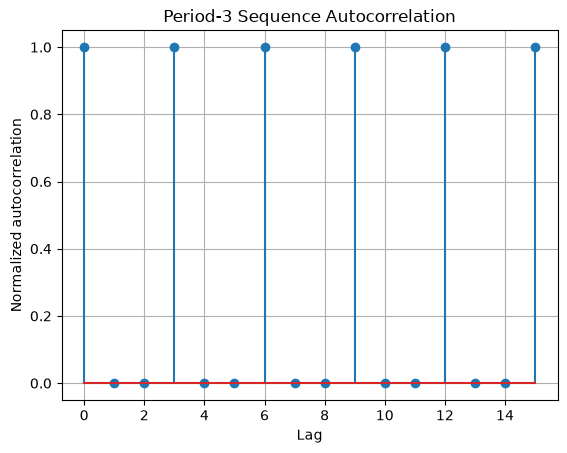

In [7]:
lags = np.arange(len(r))

plt.stem(lags, r)
plt.xlabel("Lag")
plt.ylabel("Normalized autocorrelation")
plt.title("Period-3 Sequence Autocorrelation")
plt.grid()
plt.show()

In [9]:
## complex tone

fs = 1000
f = 125
n = np.arange(1000)

iq = np.exp(1j * 2*np.pi*f*n/fs)

r_iq = normalized_autocorrelation(iq, max_lag=4)

print("Correlation:")
print(r_iq)

print("\nAngle of R[1]:", np.angle(r_iq[1]))
print("Expected angle:", 2*np.pi*f/fs)

Correlation:
[ 1.00000000e+00+0.00000000e+00j  7.07106781e-01+7.07106781e-01j
 -9.55314652e-16+1.00000000e+00j -7.07106781e-01+7.07106781e-01j
 -1.00000000e+00+1.31525465e-15j]

Angle of R[1]: 0.7853981633974483
Expected angle: 0.7853981633974483


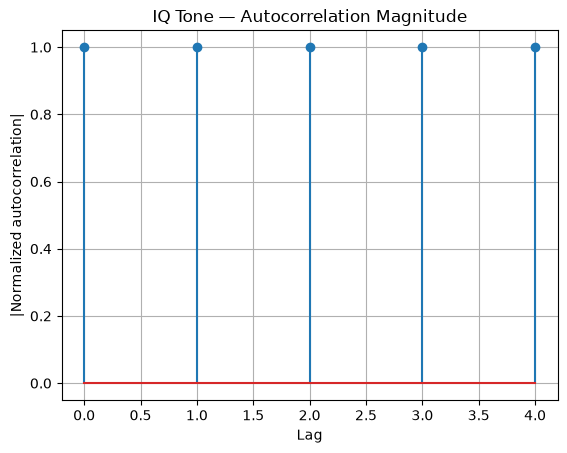

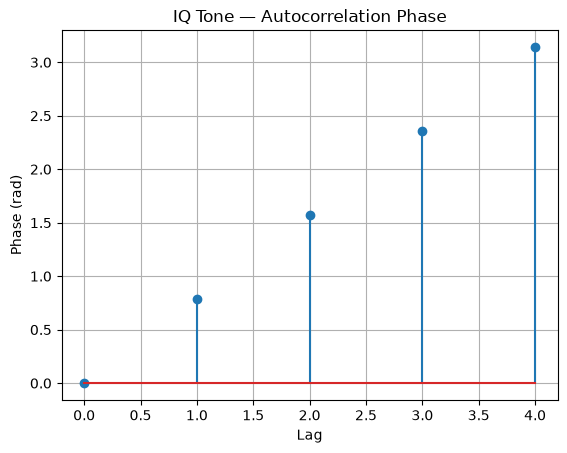

In [11]:
lags = np.arange(len(r_iq))

plt.stem(lags, np.abs(r_iq))
plt.xlabel("Lag")
plt.ylabel("|Normalized autocorrelation|")
plt.title("IQ Tone — Autocorrelation Magnitude")
plt.grid()
plt.show()

plt.stem(lags, np.angle(r_iq))
plt.xlabel("Lag")
plt.ylabel("Phase (rad)")
plt.title("IQ Tone — Autocorrelation Phase")
plt.grid()
plt.show()

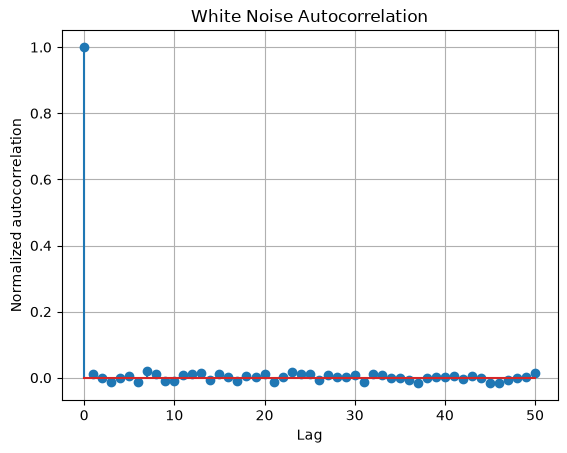

Largest non-zero-lag magnitude: 0.02005944477753974


In [12]:
## white noise

rng = np.random.default_rng(42)

noise = rng.normal(size=10000)

r_noise = normalized_autocorrelation(
    noise,
    max_lag=50
)

plt.stem(
    np.arange(len(r_noise)),
    r_noise
)

plt.xlabel("Lag")
plt.ylabel("Normalized autocorrelation")
plt.title("White Noise Autocorrelation")
plt.grid()
plt.show()

print(
    "Largest non-zero-lag magnitude:",
    np.max(np.abs(r_noise[1:]))
)